In [175]:
# Import Libraries 
import os 

import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [3]:
#Leer archivo de performance de estudiantes
ruta = os.path.join(".", "StudentsPerformance.csv") #construye ruta de archivos compatible con diferentes sistemas operativos.
df = pd.read_csv(ruta, sep=",") #Lee el archivo y lo guarda en un DataFrame de Pandas. 

In [4]:
df.columns # Columnas del dataframe

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
df.sample(20) #Visualizar 20 registros al azar

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
926,male,group E,associate's degree,free/reduced,none,64,56,52
713,male,group D,master's degree,standard,none,81,81,84
896,male,group B,high school,free/reduced,none,36,29,27
25,male,group A,master's degree,free/reduced,none,73,74,72
39,male,group B,associate's degree,free/reduced,none,57,56,57
928,male,group E,associate's degree,free/reduced,completed,46,43,44
840,female,group D,high school,free/reduced,none,39,52,46
138,female,group C,associate's degree,standard,none,59,66,67
2,female,group B,master's degree,standard,none,90,95,93
628,male,group D,some college,free/reduced,none,49,57,46


In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [14]:
df.isnull().sum() # Conocer cantidad de datos nulos

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

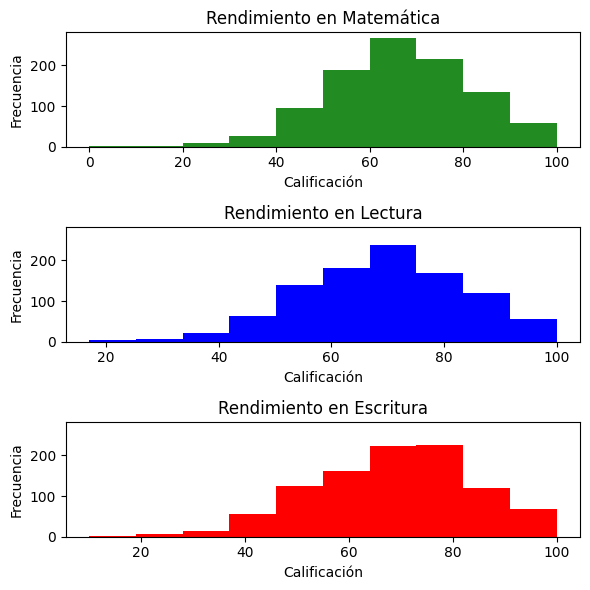

In [67]:
# Histograma de frecuencias
fig, ax = plt.subplots(3,1,figsize=(6, 6), sharey = True)
matematica= df['math score']
lectura = df['reading score']
escritura = df['writing score']
matematica.plot.hist(bins= 10, color='forestgreen',ax=ax[0],title = 'Rendimiento en Matemática')
ax[0].set_ylabel('Frecuencia')
ax[0].set_xlabel('Calificación')
lectura.plot.hist(bins= 10, color='blue',ax=ax[1],title = 'Rendimiento en Lectura')
ax[1].set_ylabel('Frecuencia')
ax[1].set_xlabel('Calificación')
escritura.plot.hist(bins= 10, color='red',ax=ax[2],title = 'Rendimiento en Escritura')
ax[2].set_ylabel('Frecuencia')
ax[2].set_xlabel('Calificación')
fig.tight_layout() # Mejora la visualización agregando separación entre subplots
plt.show()

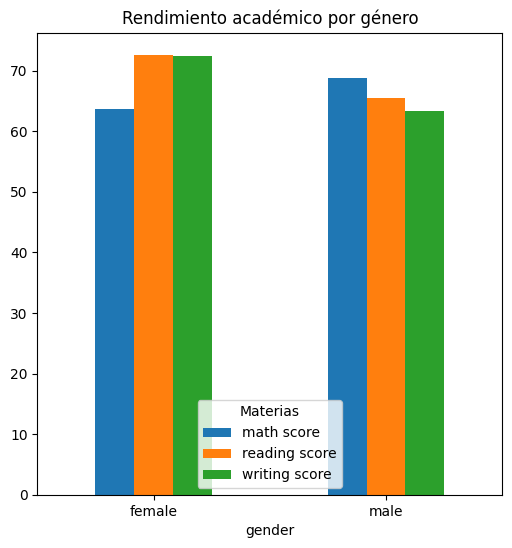

In [112]:
# El gráfico muestra el rendimiento de los estudiantes según género. 
fig, ax = plt.subplots(figsize=(6,6))
materias = ['math score', 'reading score', 'writing score']
materias_agrup = df.groupby(['gender'])[materias].mean()
materias_agrup.plot.bar(ax = ax, title ='Rendimiento académico por género', legend = True)
ax.legend(title="Materias", loc='best')
plt.xticks(rotation=0)
plt.show()


##### En el gráfico anterior podemos ver que el género femenino tiene mejor rendimiento en lectura y escritura que en Matemática. Además, en lectura y escritura tienen mejor rendimiento que los varones. 

In [118]:
print(df.columns)
df['parental level of education'].unique()

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [134]:
# Se crea una nueva columna, Promedio_Gral
df['Promedio_Gral'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
display (df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Promedio_Gral
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


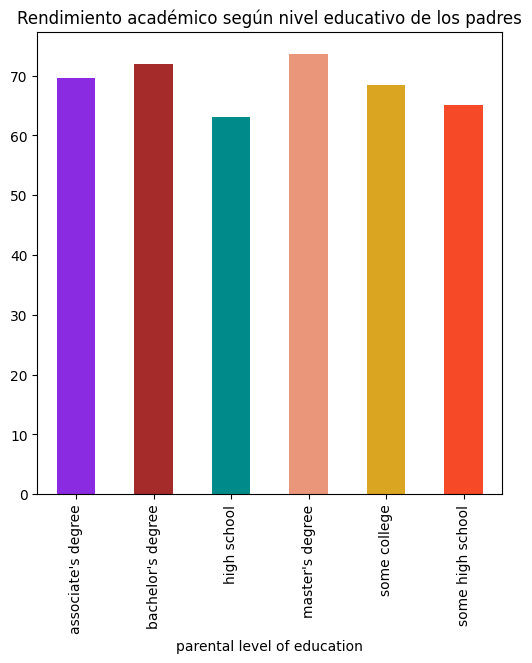

In [130]:
# Se hace un gráfico que relacione el nivel educativo de los padres y el rendimiento general de los estudiantes.
fig, ax = plt.subplots(figsize=(6,6))
colores = ["#8A2BE2","#A52A2A","#008B8B","#E9967A","#DAA520","#F54927"]
prom_materia = df.groupby(['parental level of education'])['Promedio_Gral'].mean()
prom_materia.plot.bar(ax = ax, title ='Rendimiento académico según nivel educativo de los padres', color = colores)
plt.xticks(rotation=90)
plt.show()

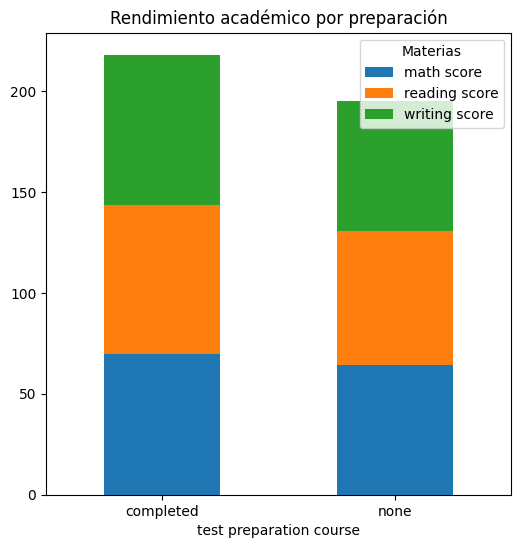

In [133]:
# El gráfico muestra el rendimiento de los estudiantes según el curso de ingreso. 
fig, ax = plt.subplots(figsize=(6,6))
materias = ['math score', 'reading score', 'writing score']
materias_agrup = df.groupby(['test preparation course'])[materias].mean()
materias_agrup.plot.bar(ax = ax, title ='Rendimiento académico por preparación', legend = True, stacked= True)
ax.legend(title="Materias", loc='best')
plt.xticks(rotation=0)
plt.show()

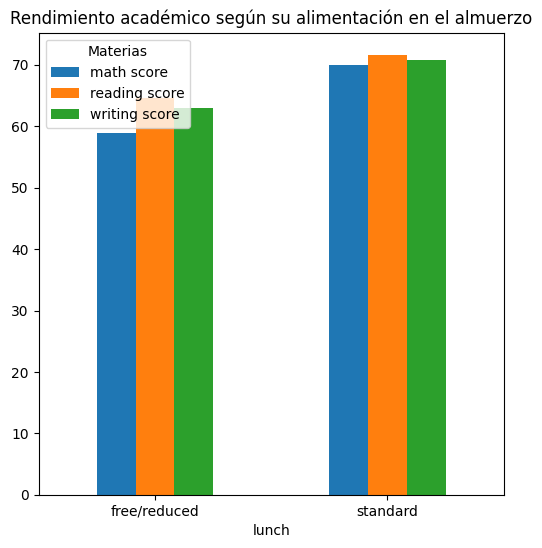

In [152]:
# El gráfico muestra el rendimiento de los estudiantes según el tipo de almuerzo que tienen. 
fig, ax = plt.subplots(figsize=(6,6))
materias = ['math score', 'reading score', 'writing score']
materias_agrup = df.groupby(['lunch'])[materias].mean()
materias_agrup.plot.bar(ax = ax, title ='Rendimiento académico según su alimentación en el almuerzo', legend = True)
ax.legend(title="Materias", loc='best')
plt.xticks(rotation=0)
plt.show()

np.float64(100.0)

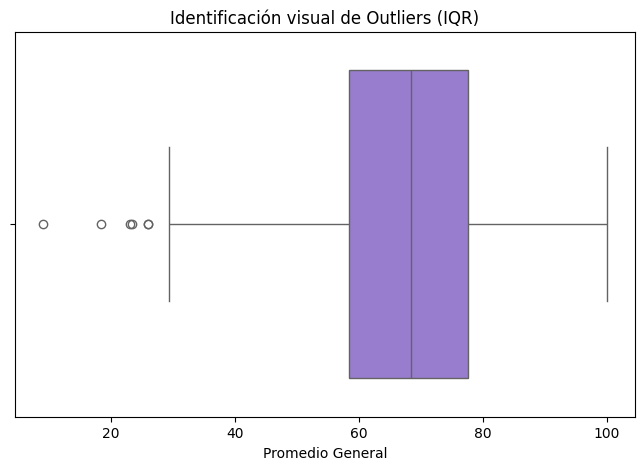

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Se grafica el Promedio_Gral 
sns.boxplot(x=df['Promedio_Gral'], color='mediumpurple')

plt.title('Identificación visual de Outliers (IQR)')
plt.xlabel('Promedio General')
plt.show()

In [146]:
# Transformación de la característica gender con Label Encoder()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['gender'])
le.classes_
df['gender_update'] = le.transform(df['gender'])
display(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Promedio_Gral,gender_update
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,0
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,1
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,0
998,female,group D,some college,standard,completed,68,78,77,74.333333,0


In [148]:
# Transformación de la característica test preparation course con Label Encoder(). 0 para completed, 1 para none. 
le = LabelEncoder()
le.fit(df['test preparation course'])
le.classes_
df['test_prep_update'] = le.transform(df['test preparation course'])
display(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Promedio_Gral,gender_update,test_prep_update
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,0,0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1,1
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,0,0
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,1,1
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,0,0
998,female,group D,some college,standard,completed,68,78,77,74.333333,0,0


In [151]:
# Transformación de la característica lunch  con Label Encoder(). 0 para free/reduced 1 para completed. 
le = LabelEncoder()
le.fit(df['lunch'])
le.classes_
df['lunch_update'] = le.transform(df['lunch'])
display(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Promedio_Gral,gender_update,test_prep_update,lunch_update
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0,1,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,0,0,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0,1,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1,1,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,0,0,1
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,1,1,0
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,0,0,0
998,female,group D,some college,standard,completed,68,78,77,74.333333,0,0,1


In [159]:
# Se aplica One-Hot Encoding para la columna relativa a la etnia
# El prefijo ayuda a saber de dónde venía la columna en tu portfolio

df= pd.get_dummies(df, columns=['race/ethnicity'], prefix='etnia',drop_first=True,dtype = int)

print(df.sample(10))

     gender parental level of education         lunch test preparation course  \
282  female           bachelor's degree  free/reduced                    none   
226  female                some college      standard                    none   
736    male          associate's degree      standard                    none   
360  female                 high school      standard                    none   
732  female                some college      standard               completed   
26     male                some college      standard                    none   
518  female            some high school      standard               completed   
92     male                 high school      standard                    none   
430    male          associate's degree  free/reduced                    none   
11     male          associate's degree      standard                    none   

     math score  reading score  writing score  Promedio_Gral  gender_update  \
282          73             7

In [161]:
df.dtypes
# df_model = 

gender                          object
parental level of education     object
lunch                           object
test preparation course         object
math score                       int64
reading score                    int64
writing score                    int64
Promedio_Gral                  float64
gender_update                    int64
test_prep_update                 int64
lunch_update                     int64
etnia_group B                    int64
etnia_group C                    int64
etnia_group D                    int64
etnia_group E                    int64
dtype: object

In [162]:
# Se crea el dataframe solo con los datos enteros y float
df_model = df.select_dtypes(include=['int', 'float'])
display(df_model)

,math score,reading score,writing score,Promedio_Gral,gender_update,test_prep_update,lunch_update,etnia_group B,etnia_group C,etnia_group D,etnia_group E
0,72,72,74,72.666667,0,1,1,1,0,0,0
1,69,90,88,82.333333,0,0,1,0,1,0,0
2,90,95,93,92.666667,0,1,1,1,0,0,0
3,47,57,44,49.333333,1,1,0,0,0,0,0
4,76,78,75,76.333333,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
995,88,99,95,94.000000,0,0,1,0,0,0,1
996,62,55,55,57.333333,1,1,0,0,1,0,0
997,59,71,65,65.000000,0,0,0,0,1,0,0
998,68,78,77,74.333333,0,0,1,0,0,1,0


In [168]:
df_model = df_model.drop(columns=['reading score','writing score','Promedio_Gral'], axis=1)

KeyError: "['reading score', 'writing score', 'Promedio_Gral'] not found in axis"

In [178]:
X = df_model.drop(columns=['math score'])
Y = df_model['math score']

In [179]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [180]:
# Estandarizar los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_train_scaled = standardizer.fit_transform(X_train)
X_test_scaled = standardizer.transform(X_test)

In [177]:
display (X_train_scaled)

array([[-0.29945237, -0.94880848,  0.73178456, ..., -0.69388867,
         1.72058015, -0.41181385],
       [-0.03305048, -0.94880848, -1.36652242, ...,  1.44115338,
        -0.58119931, -0.41181385],
       [ 0.83275564, -0.94880848,  0.73178456, ..., -0.69388867,
         1.72058015, -0.41181385],
       ...,
       [-0.89885661, -0.94880848,  0.73178456, ...,  1.44115338,
        -0.58119931, -0.41181385],
       [-1.09865802,  1.05395348, -1.36652242, ...,  1.44115338,
        -0.58119931, -0.41181385],
       [ 1.23235847, -0.94880848,  0.73178456, ..., -0.69388867,
         1.72058015, -0.41181385]], shape=(800, 8))

In [181]:
#Se entrena el modelo
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train_scaled, Y_train)
modelo.score(X_train_scaled, Y_train)

0.24397638627770069

In [182]:
from sklearn.metrics import mean_absolute_error

Y_pred = modelo.predict(X_test_scaled)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"El modelo se equivoca, en promedio, por {mae:.2f} puntos.")

El modelo se equivoca, en promedio, por 11.47 puntos.


In [185]:
import pandas as pd

# Creamos el DataFrame 'importancia'
# X.columns contiene las variables, # modelo.coef_ contiene los pesos numéricos que calculó la Regresión

importancia = pd.DataFrame({
    'Factor': X.columns,
    'Peso (Impacto)': modelo.coef_
})

# Se ordena de mayor a mayor impacto para que el gráfico sea legible
importancia = importancia.sort_values(by='Peso (Impacto)', ascending=False)

print(importancia)

             Factor  Peso (Impacto)
2      lunch_update        5.453223
6     etnia_group E        3.416152
0     gender_update        2.169549
5     etnia_group D        1.728393
4     etnia_group C        0.466243
3     etnia_group B        0.045209
1  test_prep_update       -2.935789


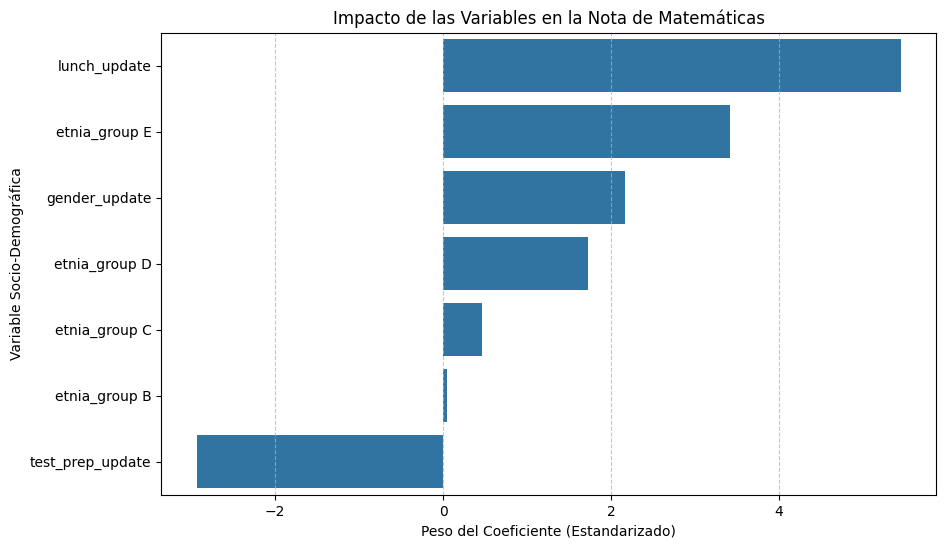

In [187]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso (Impacto)', y='Factor', data=importancia)
plt.title('Impacto de las Variables en la Nota de Matemáticas')
plt.xlabel('Peso del Coeficiente (Estandarizado)')
plt.ylabel('Variable Socio-Demográfica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### El análisis de regresión lineal permitió identificar los factores que más influyen en el desempeño matemático de los estudiantes.
#####  Impacto Socioeconómico: El tipo de almuerzo resultó ser la variable con mayor peso predictivo ($+5.45$ puntos), confirmando que las condiciones materiales son determinantes para el aprendizaje.
##### Contexto Étnico-Cultural: Se observa una ventaja significativa en el Grupo E ($+3.41$), lo que abre la puerta a investigar qué prácticas pedagógicas o familiares en este grupo fomentan el éxito en exactas.
#####  Intervención Pedagógica: El curso de preparación presenta un coeficiente negativo ($-2.93$), lo que sugiere que podría estar siendo utilizado como medida remedial para alumnos con rezago previo, más que como una herramienta de aceleración.